In [1]:
#Seaborn improves the look of our graphs in matplotlib. 
#'Matplotlib inline' creates inline plots in our notebook output instead of popup plot. 
#This removes the need to write plt.show() every time we want a plot to appear.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn

%matplotlib inline

In [2]:
df = pd.read_csv("superstore_sales.csv", encoding ='latin')
df.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62


In [3]:
#to reset the table so it has a new index (sorted by Country)
df.set_index('Order ID').head(2)

,Row ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
Order ID,,,,,,,,,,,,,,,,,
CA-2017-152156,1,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96
CA-2017-152156,2,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94


In [4]:
# to get the data types of each column
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object

In [5]:
#To clean up the data. Check if any columns are missing values.
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [6]:
#Q2. to plot by 'Segments' according to 'Sales'.  Included extra column - 'category'.
df_segment = df[["Segment", "Sales","Category"]]
df_segment.groupby(["Segment","Category"]).sum().round(2)

Sales
Segment     Category                  
Consumer    Furniture        387696.26
            Office Supplies  359352.61
            Technology       401011.66
Corporate   Furniture        220321.70
            Office Supplies  224130.54
            Technology       244041.84
Home Office Furniture        120640.62
            Office Supplies  121939.19
            Technology       182402.37

<Axes: xlabel='Segment'>

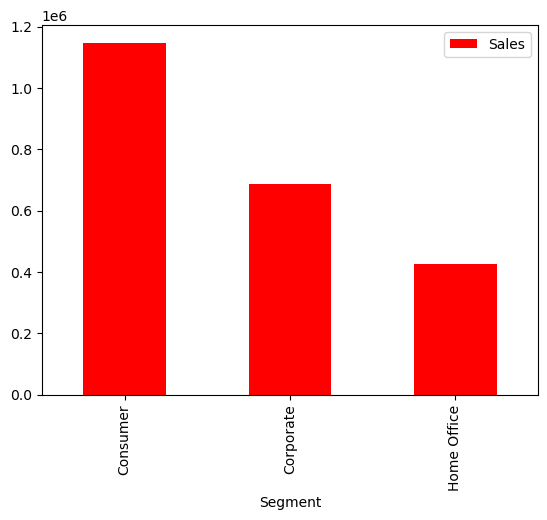

In [7]:
#Q3. to plot by 'Segments' according to 'Sales'
df_segment.groupby(["Segment"]).sum().plot(kind='bar', color='red')

<Axes: xlabel='Category'>

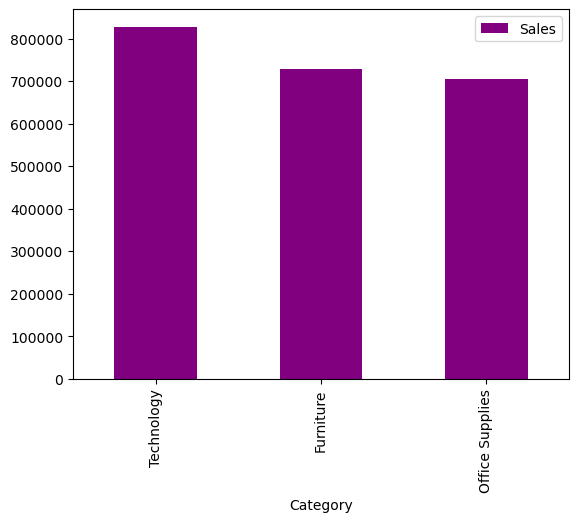

In [8]:
#Q4. Sum the revenue buy each category & plot by Sales.
df_revenue = df[["Category","Sales"]]
df_revenue.groupby("Category").sum().sort_values("Sales", ascending=False).plot(kind='bar',color='purple')

In [9]:
#Q5. To get region with Sales total (by highest amount of sales).
df_region = df[['Region', 'Sales']]
df_region.groupby(['Region']).sum().sort_values( by ='Sales', ascending=False)

,Sales
Region,
West,710219.6845
East,669518.7260
Central,492646.9132
South,389151.4590


In [10]:
#Q5. First convert the date column into datetime type.
df['Order Date'] = pd.to_datetime(df['Order Date'],format='%d/%m/%y', errors = 'ignore')
df['Order Date'].head()

C:\Users\Tim\AppData\Local\Temp\ipykernel_23128\4202235682.py:2: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df['Order Date'] = pd.to_datetime(df['Order Date'],format='%d/%m/%y', errors = 'ignore')


0    08/11/2017
1    08/11/2017
2    12/06/2017
3    11/10/2016
4    11/10/2016
Name: Order Date, dtype: object

In [11]:
#Q5. What was sold in 2018 & where it was sold.
df_2018 = df.loc[(df['Order Date'] > '01/01/2017')& (df['Order Date'] <= '01/01/2019')]
df_2018.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
848,849,CA-2018-107503,01/01/2018,06/01/2018,Standard Class,GA-14725,Guy Armstrong,Consumer,United States,Lorain,Ohio,44052.0,East,FUR-FU-10003878,Furniture,Furnishings,"Linden 10"" Round Wall Clock, Black",48.896
4009,4010,CA-2018-144463,01/01/2018,05/01/2018,Standard Class,SC-20725,Steven Cartwright,Consumer,United States,Los Angeles,California,90036.0,West,FUR-FU-10001215,Furniture,Furnishings,"Howard Miller 11-1/2"" Diameter Brentwood Wall ...",474.430
6682,6683,CA-2018-154466,01/01/2018,02/01/2018,First Class,DP-13390,Dennis Pardue,Home Office,United States,Franklin,Wisconsin,53132.0,Central,OFF-BI-10002012,Office Supplies,Binders,Wilson Jones Easy Flow II Sheet Lifters,3.600


In [12]:
#Q6.  What & where sold in 2018.
df_2018sold = df_2018[["Product Name","City"]]
df_2018sold

,Product Name,City
848,"Linden 10"" Round Wall Clock, Black",Lorain
4009,"Howard Miller 11-1/2"" Diameter Brentwood Wall ...",Los Angeles
6682,Wilson Jones Easy Flow II Sheet Lifters,Franklin
8069,SAFCO Boltless Steel Shelving,Huntsville
8070,"Tenex Carpeted, Granite-Look or Clear Contempo...",Huntsville
8071,Office Star - Contemporary Task Swivel Chair,Huntsville
8072,Fluorescent Highlighters by Dixon,Huntsville
8073,GBC Instant Report Kit,Huntsville
8074,"Pressboard Covers with Storage Hooks, 9 1/2"" x...",Huntsville
8075,Fellowes Superior 10 Outlet Split Surge Protector,Huntsville


In [13]:
#Q7. What furniture was sold in Vermont over $1,000. 
df_vermont = df.loc[(df['State'] == 'Vermont') & (df['Category'] == 'Furniture') & (df['Sales'] > 1000), 
                                     ['State', 'Category', 'Sales']]
df_vermont

,State,Category,Sales
9741,Vermont,Furniture,4404.9


<Axes: >

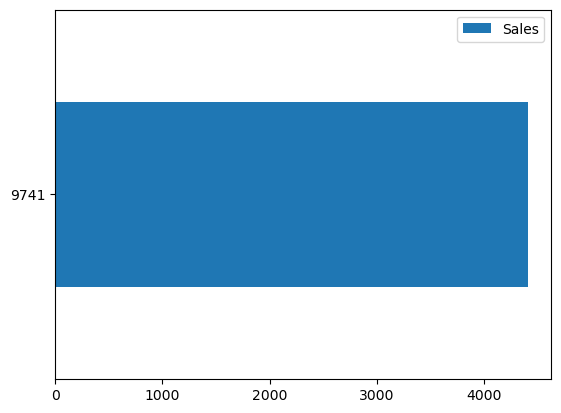

In [14]:
#Q6. 
df_vermont.plot(kind='barh')